# Análisis de Exportaciones por Entidad Federativa (INEGI)

## Descripción
Este proyecto analiza las exportaciones anuales por entidad federativa y subsector económico, utilizando datos oficiales del INEGI para el período 2007-2025. El objetivo es identificar patrones de exportación, concentración geográfica y sectorial, así como la evolución de la disponibilidad de la información.

## Fuente de datos
- **INEGI**: Estadísticas de Exportaciones Anuales por Entidad Federativa. Entidad y Subsector
- **Período**: 2007-2025
- **Fuentes**:
  - https://www.inegi.org.mx/datosabiertos/
  - https://www.inegi.org.mx/contenidos/programas/exporta_ef/datosabiertos/conjunto_de_datos_eef_csv.zip

## Estructura del dataset
- **11 columnas** con información de exportaciones
- **16,416 registros**
- **Período**: 2007-2025 (19 años)
- **Cobertura**: 32 entidades federativas

## Hallazgos clave

### 1. Tendencia de confidencialidad
La proporción de registros confidenciales ha mostrado una tendencia decreciente:
- **Pico máximo**: 27.90% en 2012
- **Pico mínimo**: 19.84% en 2024
- **Conclucion**: Los datos son cada vez más accesibles para el análisis público

### 2. Distribución geográfica de exportaciones
Las exportaciones están altamente concentradas en unos pocos estados:
- **Top 3 estados** concentran el 34.84% de las exportaciones totales
- **Principales estados exportadores**:
  1. Chihuahua:: 972.43 M USD
  2. Coahuila de Zaragoza: 762.51 M USD
  3. Baja California: 755.98 M USD

### 3. Concentración sectorial
La actividad exportadora está dominada por unos pocos sectores:
- **Top 5 sectores** concentran el 62.79% de las exportaciones totales
- **Sectores con mayor exportación**:
  1. Fabricacion de equipo de transporte: 35.71 %
  2. Fabricación de equipo de computación, comunicación, medición y de otros equipos, componentes y accesorios electrónicos: 19.30 %
  3. Extraccion de petrole y gas: 7.78 % 

## Archivos incluidos
- `eef_consolidado_final.csv`: Dataset limpio y consolidado
- `diccionario_datos.csv`: Diccionario de datos con descripción de cada columna
- `resumen_anios.csv`: Conteo de registros por año
- `exportaciones_por_estado.csv`: Exportaciones totales por entidad federativa
- `exportaciones_por_sector.csv`: Exportaciones totales por sector económico
- `comparacion_disponible_confidencial.csv`: Comparación por año de registros disponibles vs confidenciales

## Tecnologías utilizadas
- **Python 3.x**: Procesamiento y análisis de datos
- **Pandas**: Manipulación y consolidación de datos
- **Matplotlib**: Visualización de datos
- **Power BI**: Dashboard interactivo (pendiente)

## Autor
Humberto Isaac Padilla contreras - @LovecraftianCode

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cargar y unir datos
df = pd.read_csv('eef_estatal_anual_tr_cifra_2007_2025.csv')
df_codigos = pd.read_csv('tc_scian.csv')
df_entidades = pd.read_csv('tc_entidad.csv')

df = df.merge(df_codigos[['CODIGO_SCIAN', 'DESCRIPCION']], on='CODIGO_SCIAN', how='left')
df = df.merge(df_entidades[['CVE_ENT', 'NOM_ENTIDAD']], on='CVE_ENT', how='left')

# Reordenar columnas
orden_final = ['PROD_EST', 'COBERTURA', 'ANIO', 'CVE_ENT', 'NOM_ENTIDAD', 
               'CODIGO_SCIAN', 'DESCRIPCION', 'VAL_USD', 'ESTATUS_CIFRA', 
               'ESTATUS']
df = df[orden_final]

# Tabla 1: Resumen completo por año (todas las filas)
df_resumen_anios = pd.DataFrame({
    'AÑO': sorted(df['ANIO'].unique()),
    'TOTAL_FILAS': [df[df['ANIO'] == año].shape[0] for año in sorted(df['ANIO'].unique())],
    'REGISTROS_CON_VALOR': [df[df['ANIO'] == año]['VAL_USD'].count() for año in sorted(df['ANIO'].unique())],
    'REGISTROS_SIN_VALOR': [df[df['ANIO'] == año]['VAL_USD'].isna().sum() for año in sorted(df['ANIO'].unique())]
})

# Tabla 2: Estadisticas de VAL_USD (solo registros con valor)
df_estadisticas = df.groupby('ANIO')['VAL_USD'].agg(['count', 'sum', 'mean']).round(2)
df_estadisticas.columns = ['Registros_con_valor', 'Suma_USD', 'Promedio_USD']

# Mostrar resultados
print("=" * 60)
print("RESUMEN COMPLETO POR AÑO")
print("=" * 60)
print(df_resumen_anios.to_string(index=False))
print("\n")

print("=" * 60)
print("ESTADISTICAS DE VAL_USD POR AÑO")
print("=" * 60)
print(df_estadisticas)
print("\n")

print("=" * 60)
print("VERIFICACION")
print("=" * 60)
print("Cada año tiene 864 filas totales en el dataset original.")
print("La columna 'REGISTROS_CON_VALOR' debe coincidir con 'Registros_con_valor' de la segunda tabla.")
print("La diferencia son los registros sin dato en VAL_USD.")

# Guardar
df.to_csv('eef_consolidado_final.csv', index=False)
df_resumen_anios.to_csv('resumen_anios.csv', index=False)
df_estadisticas.to_csv('estadisticas_anios.csv', index=True)
print("\nArchivos guardados:")
print("- eef_consolidado_final.csv")
print("- resumen_anios.csv")
print("- estadisticas_anios.csv")

RESUMEN COMPLETO POR AÑO
 AÑO  TOTAL_FILAS  REGISTROS_CON_VALOR  REGISTROS_SIN_VALOR
2007          864                  389                  475
2008          864                  412                  452
2009          864                  420                  444
2010          864                  406                  458
2011          864                  404                  460
2012          864                  398                  466
2013          864                  419                  445
2014          864                  417                  447
2015          864                  417                  447
2016          864                  412                  452
2017          864                  430                  434
2018          864                  501                  363
2019          864                  487                  377
2020          864                  498                  366
2021          864                  505                  359
2022          8

In [2]:
# Comparar: registros sin VAL_USD vs registros con ESTATUS_CIFRA != 'Disponible'
sin_valor = df['VAL_USD'].isna().sum()
no_disponible = df[df['ESTATUS_CIFRA'] != 'Disponible'].shape[0]

print("=" * 80)
print("COMPARACION DIRECTA registros sin VAL_USD vs VAL_USD diferentes a Disponible")
print("=" * 80)
print(f"Registros sin VAL_USD: {sin_valor}")
print(f"Registros con ESTATUS_CIFRA != 'Disponible': {no_disponible}")
print(f"Diferencia: {abs(sin_valor - no_disponible)}")

COMPARACION DIRECTA registros sin VAL_USD vs VAL_USD diferentes a Disponible
Registros sin VAL_USD: 7934
Registros con ESTATUS_CIFRA != 'Disponible': 7934
Diferencia: 0


In [3]:
# Filtrar solo los registros que son Disponible o Confidencial
df_filtrado = df[df['ESTATUS_CIFRA'].isin(['Disponible', 'Confidencial'])]

# Contar por año y estatus
comparacion_estatus = df_filtrado.groupby(['ANIO', 'ESTATUS_CIFRA']).size().unstack(fill_value=0)

# Renombrar columnas para claridad
comparacion_estatus.columns = ['Confidencial', 'Disponible']

# Agregar columna de total
comparacion_estatus['Total'] = comparacion_estatus['Confidencial'] + comparacion_estatus['Disponible']

# Agregar columna de porcentaje de confidenciales
comparacion_estatus['%_Confidencial'] = (comparacion_estatus['Confidencial'] / comparacion_estatus['Total'] * 100).round(2)

print("=" * 70)
print("COMPARACION: DISPONIBLE VS CONFIDENCIAL POR AÑO")
print("=" * 70)
print(comparacion_estatus)

COMPARACION: DISPONIBLE VS CONFIDENCIAL POR AÑO
      Confidencial  Disponible  Total  %_Confidencial
ANIO                                                 
2007           134         389    523           25.62
2008           126         412    538           23.42
2009           127         420    547           23.22
2010           143         406    549           26.05
2011           148         404    552           26.81
2012           154         398    552           27.90
2013           119         419    538           22.12
2014           126         417    543           23.20
2015           128         417    545           23.49
2016           134         412    546           24.54
2017           119         430    549           21.68
2018           149         501    650           22.92
2019           155         487    642           24.14
2020           147         498    645           22.79
2021           133         505    638           20.85
2022           138         495    

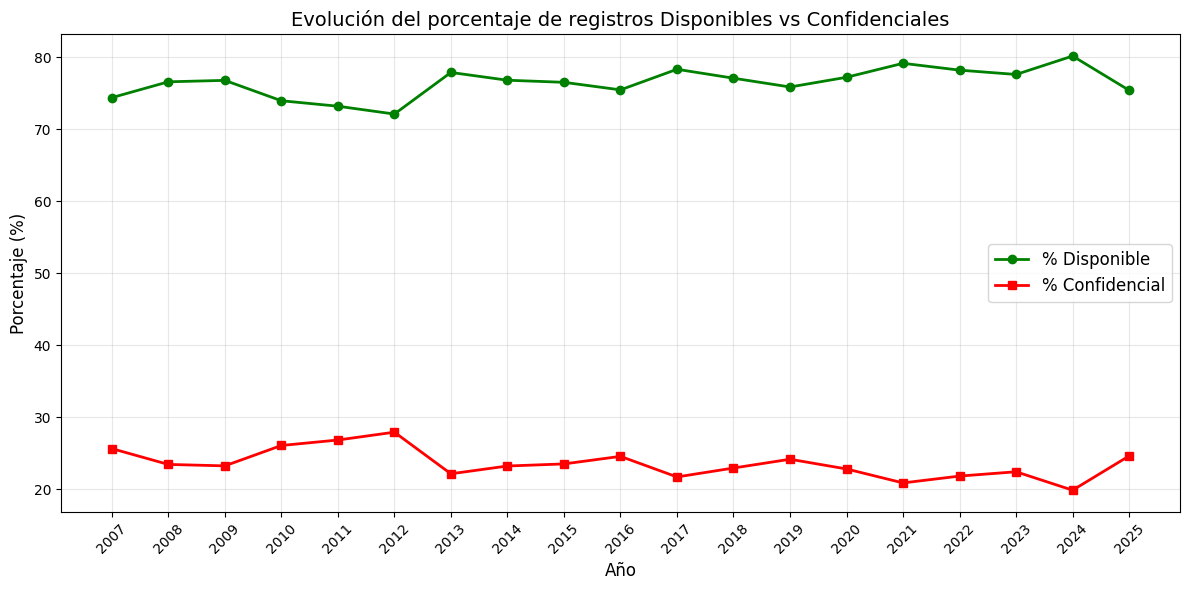

PORCENTAJES POR AÑO
      %_Disponible  %_Confidencial
ANIO                              
2007         74.38           25.62
2008         76.58           23.42
2009         76.78           23.22
2010         73.95           26.05
2011         73.19           26.81
2012         72.10           27.90
2013         77.88           22.12
2014         76.80           23.20
2015         76.51           23.49
2016         75.46           24.54
2017         78.32           21.68
2018         77.08           22.92
2019         75.86           24.14
2020         77.21           22.79
2021         79.15           20.85
2022         78.20           21.80
2023         77.60           22.40
2024         80.16           19.84
2025         75.40           24.60


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Calcular porcentaje de confidenciales por año
comparacion_estatus['Total'] = comparacion_estatus['Disponible'] + comparacion_estatus['Confidencial']
comparacion_estatus['%_Confidencial'] = (comparacion_estatus['Confidencial'] / comparacion_estatus['Total'] * 100).round(2)
comparacion_estatus['%_Disponible'] = (comparacion_estatus['Disponible'] / comparacion_estatus['Total'] * 100).round(2)

# Gráfico de líneas con porcentajes
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(comparacion_estatus.index, comparacion_estatus['%_Disponible'], 
        marker='o', linewidth=2, label='% Disponible', color='green')
ax.plot(comparacion_estatus.index, comparacion_estatus['%_Confidencial'], 
        marker='s', linewidth=2, label='% Confidencial', color='red')

ax.set_title('Evolución del porcentaje de registros Disponibles vs Confidenciales', fontsize=14)
ax.set_xlabel('Año', fontsize=12)
ax.set_ylabel('Porcentaje (%)', fontsize=12)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_xticks(comparacion_estatus.index)
ax.set_xticklabels(comparacion_estatus.index, rotation=45)

plt.tight_layout()
plt.show()

print("=" * 70)
print("PORCENTAJES POR AÑO")
print("=" * 70)
print(comparacion_estatus[['%_Disponible', '%_Confidencial']])

In [5]:
# Identificar el año con mayor y menor porcentaje de confidenciales
max_confidencial = comparacion_estatus['%_Confidencial'].max()
min_confidencial = comparacion_estatus['%_Confidencial'].min()
año_max = comparacion_estatus[comparacion_estatus['%_Confidencial'] == max_confidencial].index[0]
año_min = comparacion_estatus[comparacion_estatus['%_Confidencial'] == min_confidencial].index[0]

print("=" * 70)
print("RESUMEN DE CONFIDENCIALIDAD")
print("=" * 70)
print(f"Año con mayor % confidencial: {año_max} ({max_confidencial:.2f}%)")
print(f"Año con menor % confidencial: {año_min} ({min_confidencial:.2f}%)")
print(f"Diferencia: {max_confidencial - min_confidencial:.2f} puntos porcentuales")

RESUMEN DE CONFIDENCIALIDAD
Año con mayor % confidencial: 2012 (27.90%)
Año con menor % confidencial: 2024 (19.84%)
Diferencia: 8.06 puntos porcentuales


In [6]:
# Diccionario de datos para documentación
diccionario = pd.DataFrame({
    'Columna': df.columns.tolist(),
    'Tipo': df.dtypes.tolist(),
    'Descripcion': [
        'Nombre del proyecto estadístico',
        'Área geográfica (Estatal)',
        'Año de referencia',
        'Clave de entidad federativa',
        'Nombre de la entidad',
        'Clave SCIAN del subsector',
        'Descripción del subsector',
        'Valor en miles de USD (FOB)',
        'Estatus de la cifra (Disponible/Confidencial/etc)',
        'Estatus de la cifra (Definitiva/Preliminar)'
    ]
})
diccionario.to_csv('diccionario_datos.csv', index=False)

In [7]:
# Exportaciones totales por estado
exportaciones_por_estado = df.groupby('NOM_ENTIDAD')['VAL_USD'].sum().round(2).sort_values(ascending=False)

df_exportaciones_estado = pd.DataFrame({
    'ENTIDAD': exportaciones_por_estado.index,
    'TOTAL_EXPORTACIONES_USD': exportaciones_por_estado.values
})

# Columnas adicionales
df_exportaciones_estado['TOTAL_MILLONES_USD'] = (df_exportaciones_estado['TOTAL_EXPORTACIONES_USD'] / 1000000).round(2)

total_global = df['VAL_USD'].sum()
df_exportaciones_estado['%_PARTICIPACION'] = (df_exportaciones_estado['TOTAL_EXPORTACIONES_USD'] / total_global * 100).round(2)

print("=" * 70)
print("EXPORTACIONES TOTALES POR ENTIDAD FEDERATIVA")
print("=" * 70)
print(df_exportaciones_estado.to_string(index=False))
print("\n")

# Resumen ejecutivo
print("=" * 70)
print("RESUMEN EJECUTIVO")
print("=" * 70)

# Top 3
top_3 = df_exportaciones_estado.head(3)
top_3_participacion = top_3['%_PARTICIPACION'].sum()

print(f"Total global de exportaciones: {total_global/1000000:.2f} Millones USD")
print(f"Top 3 estados: {', '.join(top_3['ENTIDAD'].tolist())}")
print(f"Participación del Top 3: {top_3_participacion:.2f}%")
print("\nDetalle del Top 3:")
for idx, row in top_3.iterrows():
    print(f"  - {row['ENTIDAD']}: {row['TOTAL_MILLONES_USD']:.2f} M USD ({row['%_PARTICIPACION']:.2f}%)")

EXPORTACIONES TOTALES POR ENTIDAD FEDERATIVA
                        ENTIDAD  TOTAL_EXPORTACIONES_USD  TOTAL_MILLONES_USD  %_PARTICIPACION
                      Chihuahua              972425286.0              972.43            13.60
           Coahuila de Zaragoza              762507076.0              762.51            10.67
                Baja California              755977174.0              755.98            10.57
                     Nuevo León              672536038.0              672.54             9.41
                     Tamaulipas              534436502.0              534.44             7.48
                        Jalisco              428023406.0              428.02             5.99
                     Guanajuato              397694029.0              397.69             5.56
                       Campeche              363922254.0              363.92             5.09
                         Sonora              347288881.0              347.29             4.86
               

In [25]:
# Exportaciones totales por sector (suma de VAL_USD)
exportaciones_por_sector = df.groupby('DESCRIPCION')['VAL_USD'].sum().round(2).sort_values(ascending=False)

# Convertir a DataFrame
df_exportaciones_sector = pd.DataFrame({
    'SECTOR': exportaciones_por_sector.index,
    'TOTAL_EXPORTACIONES_USD': exportaciones_por_sector.values
})

# Agregar columna con valores en millones
df_exportaciones_sector['TOTAL_MILLONES_USD'] = (df_exportaciones_sector['TOTAL_EXPORTACIONES_USD'] / 1000000).round(2)

# Calcular porcentaje de participación
total_global = df['VAL_USD'].sum()
df_exportaciones_sector['%_PARTICIPACION'] = (df_exportaciones_sector['TOTAL_EXPORTACIONES_USD'] / total_global * 100).round(2)

print("=" * 70)
print("EXPORTACIONES TOTALES POR SECTOR ECONOMICO")
print("=" * 70)
print(df_exportaciones_sector.to_string(index=False))
print("\n")

# Resumen ejecutivo
print("=" * 70)
print("RESUMEN EJECUTIVO - SECTORES")
print("=" * 70)

# Top 5 sectores
top_5 = df_exportaciones_sector.head(5)
top_5_participacion = top_5['%_PARTICIPACION'].sum()

print(f"Total global de exportaciones: {total_global/1000000:.2f} Millones USD")
print(f"Top 5 sectores: {', '.join(top_5['SECTOR'].tolist())}")
print(f"Participación del Top 5: {top_5_participacion:.2f}%")
print("\nDetalle del Top 5:")
for idx, row in top_5.iterrows():
    print(f"  - {row['SECTOR']}: {row['TOTAL_MILLONES_USD']:.2f} M USD ({row['%_PARTICIPACION']:.2f}%)")

EXPORTACIONES TOTALES POR SECTOR ECONOMICO
                                                                                                                SECTOR  TOTAL_EXPORTACIONES_USD  TOTAL_MILLONES_USD  %_PARTICIPACION
                                                                                   Fabricación de equipo de transporte             2553360999.0             2553.36            35.71
Fabricación de equipo de computación, comunicación, medición y de otros equipos, componentes y accesorios electrónicos             1379633135.0             1379.63            19.30
                                                                                          Extracción de petróleo y gas              555947112.0              555.95             7.78
                            Fabricación de accesorios, aparatos eléctricos y equipo de generación de energía eléctrica              421948160.0              421.95             5.90
                                                    

C:\Users\Humberto\AppData\Local\Temp\ipykernel_16480\990613562.py:21: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


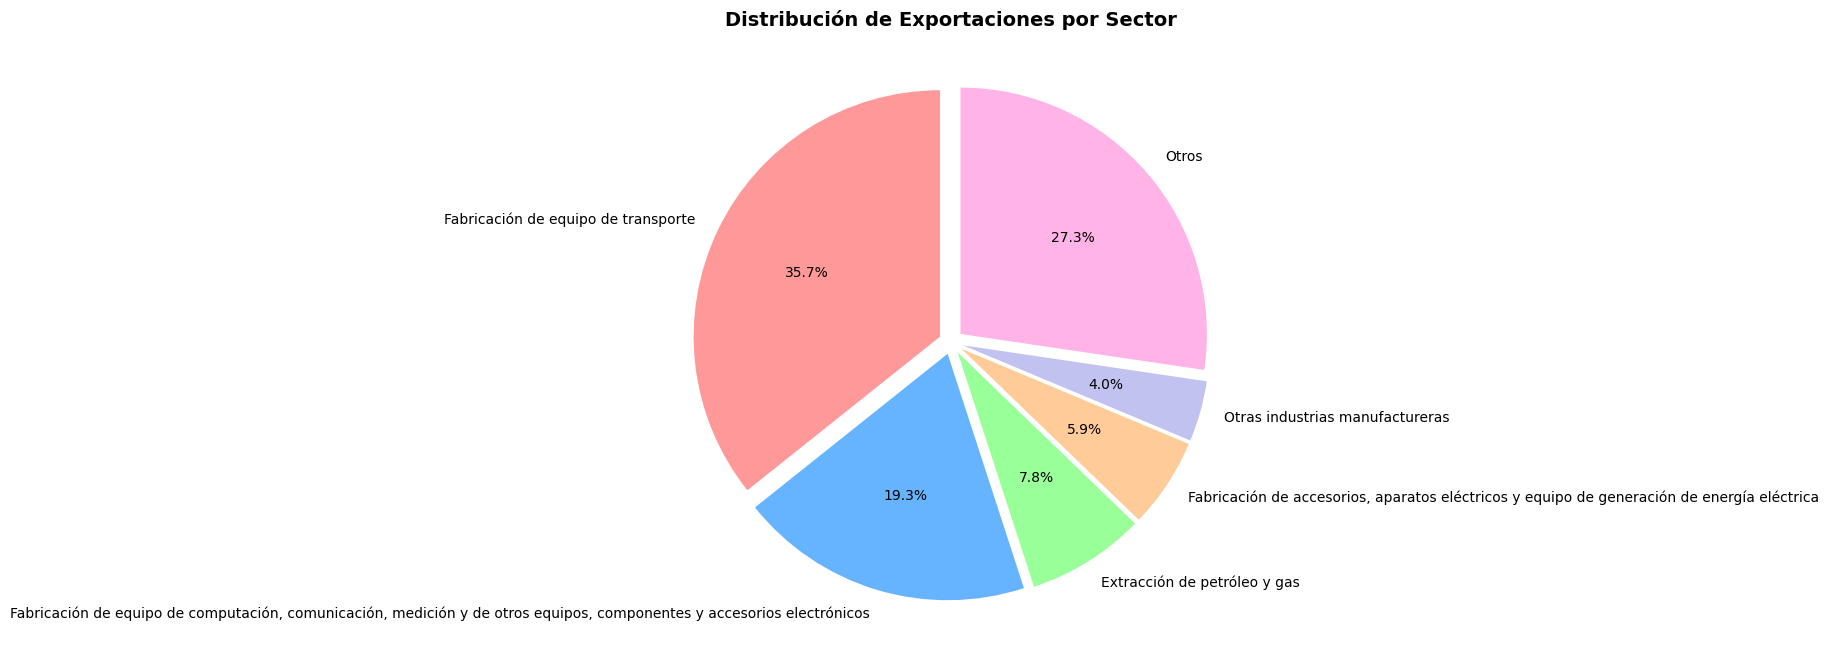

In [22]:
# Top 5 sectores + "Otros" (para no saturar)
top_5 = df_exportaciones_sector.head(5)
otros = df_exportaciones_sector.iloc[5:]['TOTAL_MILLONES_USD'].sum()

# Crear DataFrame para el pastel
datos_pastel = pd.DataFrame({
    'SECTOR': list(top_5['SECTOR']) + ['Otros'],
    'TOTAL_MILLONES_USD': list(top_5['TOTAL_MILLONES_USD']) + [otros]
})

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0','#ffb3e6']
wedges, texts, autotexts = ax.pie(datos_pastel['TOTAL_MILLONES_USD'], 
                                   labels=datos_pastel['SECTOR'], 
                                   autopct='%1.1f%%',
                                   colors=colors,
                                   startangle=90,
                                   explode=[0.05]*len(datos_pastel))

ax.set_title('Distribución de Exportaciones por Sector', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()